# WebPOS Evaluation Data Analysis

This notebook contains the analysis of sales data collected from the three participating shops.

The manual sales records and POS sales records are cleaned and analysed using Python and pandas. The analysis compares transactions, items sold and sales values between the two periods. Daily averages and a seven-recorded-sales-day moving average are also used to examine the sales data.

Ref: W. McKinney, “Data Structures for Statistical Computing in Python,” Proc. 9th Python in Science Conf. (SciPy 2010), pp. 56–61, Jan. 2010. doi: 10.25080/Majora-92bf1922-00a.

In [295]:
!pip install pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [296]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

## Manual Data

In [297]:
#Load: Manual records for 25 Jul – 24 Aug 2026
shop_a = pd.read_csv("data/shop_A.csv")
shop_b = pd.read_csv("data/shop_B.csv")
shop_c = pd.read_csv("data/shop_C.csv")

In [298]:
# Inspection
print("Shop A")
print(shop_a.head())
print("\nShop B")
print(shop_b.head())
print("\nShop C")
print(shop_c.head())

Shop A
   sale_no  order_date order_time  different_items  total_items  order_total
0        1  2026-07-25      10:07                1            5      10500.0
1        2  2026-07-25      10:11                1            1       3800.0
2        3  2026-07-25      13:47                1            1       2450.0
3        4  2026-07-25      14:14                1            2       1700.0
4        5  2026-07-25      15:51                1            2       5400.0

Shop B
   sale_no  order_date order_time  different_items  total_items  order_total
0        1  2026-07-25      08:06                1            3       2100.0
1        2  2026-07-25      08:21                3            3       7950.0
2        3  2026-07-25      08:28                1            1       2500.0
3        4  2026-07-25      08:55                1            3       9200.0
4        5  2026-07-25      09:02                3            5      10200.0

Shop C
   sale_no  order_date order_time  different_items  t

### Data Quality Checks

In [299]:
# Missing values
print("Shop A")
print(shop_a.isnull().sum())

print("\nShop B")
print(shop_b.isnull().sum())

print("\nShop C")
print(shop_c.isnull().sum())

Shop A
sale_no            0
order_date         0
order_time         0
different_items    0
total_items        0
order_total        0
dtype: int64

Shop B
sale_no            0
order_date         0
order_time         0
different_items    0
total_items        0
order_total        0
dtype: int64

Shop C
sale_no            0
order_date         0
order_time         0
different_items    0
total_items        0
order_total        0
dtype: int64


In [300]:
# Duplicates
shops = {"A": shop_a, "B": shop_b, "C": shop_c}
cols = ["order_date", "order_time", "different_items", "total_items", "order_total"]

for name, df in shops.items():
    print(f"Shop {name}")
    print("  sale_no unique:", df["sale_no"].is_unique)
    print("  Same date/time/items/total:", df.duplicated(subset=cols).sum())

Shop A
  sale_no unique: True
  Same date/time/items/total: 0
Shop B
  sale_no unique: True
  Same date/time/items/total: 0
Shop C
  sale_no unique: True
  Same date/time/items/total: 0


In [301]:
# Check invalid sales values
print((shop_a["order_total"] <= 0).sum())
print((shop_b["order_total"] <= 0).sum())
print((shop_c["order_total"] <= 0).sum())

# Check invalid item quantities
print("")
print((shop_a["total_items"] <= 0).sum())
print((shop_b["total_items"] <= 0).sum())
print((shop_c["total_items"] <= 0).sum())

# Check logical consistency
print("")
print((shop_a["different_items"] > shop_a["total_items"]).sum())
print((shop_b["different_items"] > shop_b["total_items"]).sum())
print((shop_c["different_items"] > shop_c["total_items"]).sum())

0
0
0

0
0
0

0
0
0


In [302]:
# Date convert
shop_a["order_date"] = pd.to_datetime(shop_a["order_date"])
shop_b["order_date"] = pd.to_datetime(shop_b["order_date"])
shop_c["order_date"] = pd.to_datetime(shop_c["order_date"])

print(shop_a["order_date"].dtype)
print(shop_b["order_date"].dtype)
print(shop_c["order_date"].dtype)

datetime64[ns]
datetime64[ns]
datetime64[ns]


### Summary Measures

In [303]:
# Recorded sales days
print("Shop A Recorded sales days:", shop_a["order_date"].nunique())
print("Shop B Recorded sales days:", shop_b["order_date"].nunique())
print("Shop C Recorded sales days:", shop_c["order_date"].nunique())

Shop A Recorded sales days: 29
Shop B Recorded sales days: 31
Shop C Recorded sales days: 30


In [304]:
# Summary
print("Shop A")
print("Transactions:", len(shop_a))
print("Total items:", shop_a["total_items"].sum())
print("Total sales:", shop_a["order_total"].sum())
print("Average transaction:", shop_a["order_total"].mean())
print("Average items per transaction:", shop_a["total_items"].mean())

print("\nShop B")
print("Transactions:", len(shop_b))
print("Total items:", shop_b["total_items"].sum())
print("Total sales:", shop_b["order_total"].sum())
print("Average transaction:", shop_b["order_total"].mean())
print("Average items per transaction:", shop_b["total_items"].mean())

print("\nShop C")
print("Transactions:", len(shop_c))
print("Total items:", shop_c["total_items"].sum())
print("Total sales:", shop_c["order_total"].sum())
print("Average transaction:", shop_c["order_total"].mean())
print("Average items per transaction:", shop_c["total_items"].mean())

Shop A
Transactions: 336
Total items: 712
Total sales: 1529925.0
Average transaction: 4553.348214285715
Average items per transaction: 2.119047619047619

Shop B
Transactions: 618
Total items: 1452
Total sales: 3275500.0
Average transaction: 5300.161812297734
Average items per transaction: 2.349514563106796

Shop C
Transactions: 391
Total items: 934
Total sales: 1754800.0
Average transaction: 4487.979539641944
Average items per transaction: 2.3887468030690537


In [305]:
# Daily summary

daily_a = (
    shop_a.groupby("order_date")
    .agg(
        transactions=("sale_no", "count"),
        total_items=("total_items", "sum"),
        total_sales=("order_total", "sum")
    )
    .reset_index()
)

daily_b = (
    shop_b.groupby("order_date")
    .agg(
        transactions=("sale_no", "count"),
        total_items=("total_items", "sum"),
        total_sales=("order_total", "sum")
    )
    .reset_index()
)

daily_c = (
    shop_c.groupby("order_date")
    .agg(
        transactions=("sale_no", "count"),
        total_items=("total_items", "sum"),
        total_sales=("order_total", "sum")
    )
    .reset_index()
)

print("Shop A")
print("Average transactions per recorded sales day:", daily_a["transactions"].mean())
print("Average items per recorded sales day:", daily_a["total_items"].mean())
print("Average sales per recorded sales day:", daily_a["total_sales"].mean())

print("\nShop B")
print("Average transactions per recorded sales day:", daily_b["transactions"].mean())
print("Average items per recorded sales day:", daily_b["total_items"].mean())
print("Average sales per recorded sales day:", daily_b["total_sales"].mean())

print("\nShop C")
print("Average transactions per recorded sales day:", daily_c["transactions"].mean())
print("Average items per recorded sales day:", daily_c["total_items"].mean())
print("Average sales per recorded sales day:", daily_c["total_sales"].mean())

Shop A
Average transactions per recorded sales day: 11.586206896551724
Average items per recorded sales day: 24.551724137931036
Average sales per recorded sales day: 52756.03448275862

Shop B
Average transactions per recorded sales day: 19.93548387096774
Average items per recorded sales day: 46.83870967741935
Average sales per recorded sales day: 105661.29032258065

Shop C
Average transactions per recorded sales day: 13.033333333333333
Average items per recorded sales day: 31.133333333333333
Average sales per recorded sales day: 58493.333333333336


### Moving Average

Ref: C. Chatfield, The Analysis of Time Series: An Introduction, 6th ed. New York: Chapman and Hall/CRC, Jul. 2003, doi: 10.4324/9780203491683.

In [306]:
# Calculate seven-recorded-sales-day moving average of sales

daily_a["sales_ma_7"] = daily_a["total_sales"].rolling(window=7).mean()
daily_b["sales_ma_7"] = daily_b["total_sales"].rolling(window=7).mean()
daily_c["sales_ma_7"] = daily_c["total_sales"].rolling(window=7).mean()

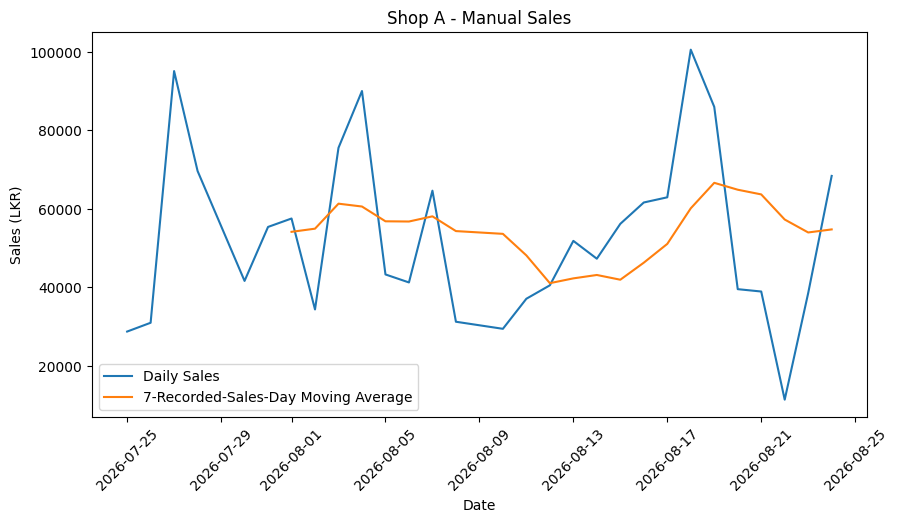

In [307]:
# Plot Shop A daily sales and moving average

plt.figure(figsize=(10, 5))

plt.plot(
    daily_a["order_date"],
    daily_a["total_sales"],
    label="Daily Sales"
)

plt.plot(
    daily_a["order_date"],
    daily_a["sales_ma_7"],
    label="7-Recorded-Sales-Day Moving Average"
)

plt.title("Shop A - Manual Sales")
plt.xlabel("Date")
plt.ylabel("Sales (LKR)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

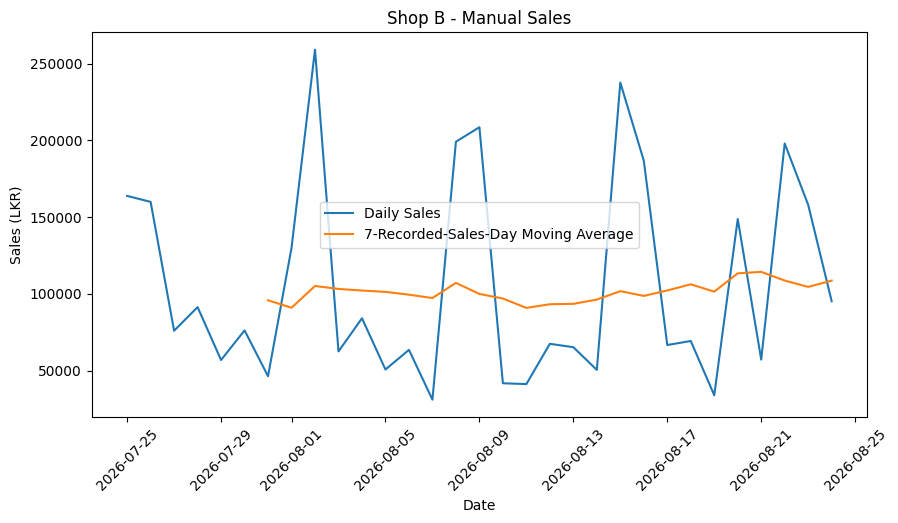

In [308]:
# Plot Shop B daily sales and moving average

plt.figure(figsize=(10, 5))

plt.plot(
    daily_b["order_date"],
    daily_b["total_sales"],
    label="Daily Sales"
)

plt.plot(
    daily_b["order_date"],
    daily_b["sales_ma_7"],
    label="7-Recorded-Sales-Day Moving Average"
)

plt.title("Shop B - Manual Sales")
plt.xlabel("Date")
plt.ylabel("Sales (LKR)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

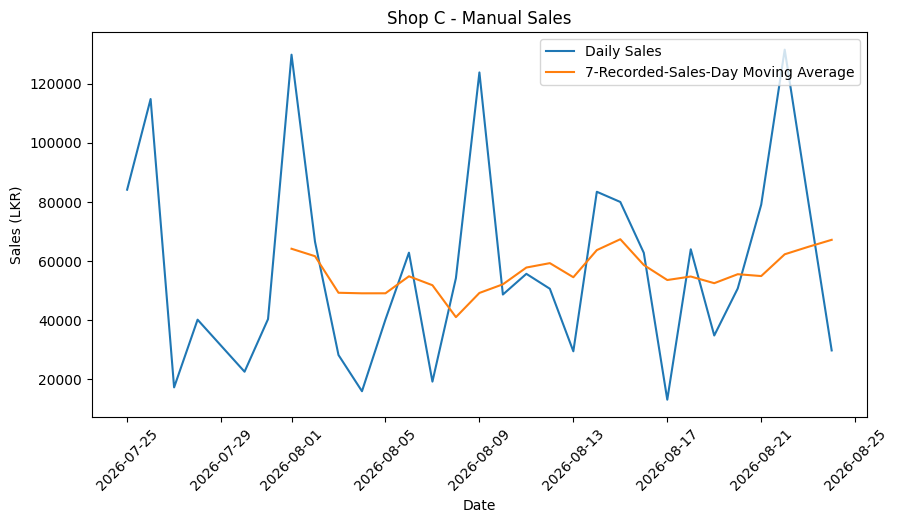

In [309]:
# Plot Shop C daily sales and moving average

plt.figure(figsize=(10, 5))

plt.plot(
    daily_c["order_date"],
    daily_c["total_sales"],
    label="Daily Sales"
)

plt.plot(
    daily_c["order_date"],
    daily_c["sales_ma_7"],
    label="7-Recorded-Sales-Day Moving Average"
)

plt.title("Shop C - Manual Sales")
plt.xlabel("Date")
plt.ylabel("Sales (LKR)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## POS Data

In [310]:
# Load: POS records for 3 Sep – 4 Oct 2026
pos_a = pd.read_csv("data/shop_A_pos.csv")
pos_b = pd.read_csv("data/shop_B_pos.csv")
pos_c = pd.read_csv("data/shop_C_pos.csv")

In [311]:
# Inspection
print("Shop A")
print(pos_a.head())
print("\nShop B")
print(pos_b.head())
print("\nShop C")
print(pos_c.head())

Shop A
   sale_no  order_date order_time  different_items  total_items  order_total
0        1  2026-09-03       8:41                2            4         8350
1        2  2026-09-03       9:17                1            1         6850
2        3  2026-09-03       9:17                1            1         6700
3        4  2026-09-03      12:22                3            4         1450
4        5  2026-09-03      12:55                1            2         6100

Shop B
   sale_no  order_date order_time  different_items  total_items  order_total
0        1  2026-09-03       8:00                3            3         5900
1        2  2026-09-03       8:16                2            3        11250
2        3  2026-09-03       8:30                1            2         4700
3        4  2026-09-03       8:53                1            2         6600
4        5  2026-09-03       9:03                2            2         4450

Shop C
   sale_no  order_date order_time  different_items  t

### Data Quality Checks

In [312]:
# Missing values
print("Shop A")
print(pos_a.isnull().sum())

print("\nShop B")
print(pos_b.isnull().sum())

print("\nShop C")
print(pos_c.isnull().sum())

Shop A
sale_no            0
order_date         0
order_time         0
different_items    0
total_items        0
order_total        0
dtype: int64

Shop B
sale_no            0
order_date         0
order_time         0
different_items    0
total_items        0
order_total        0
dtype: int64

Shop C
sale_no            0
order_date         0
order_time         0
different_items    0
total_items        0
order_total        0
dtype: int64


In [313]:
# Duplicates
pos_shops = {"A": pos_a, "B": pos_b, "C": pos_c}
cols = ["order_date", "order_time", "different_items", "total_items", "order_total"]

for name, df in pos_shops.items():
    print(f"Shop {name}")
    print("  sale_no unique:", df["sale_no"].is_unique)
    print("  Same date/time/items/total:", df.duplicated(subset=cols).sum())

Shop A
  sale_no unique: True
  Same date/time/items/total: 0
Shop B
  sale_no unique: True
  Same date/time/items/total: 0
Shop C
  sale_no unique: True
  Same date/time/items/total: 0


In [314]:
# Check invalid sales values
print((pos_a["order_total"] <= 0).sum())
print((pos_b["order_total"] <= 0).sum())
print((pos_c["order_total"] <= 0).sum())

# Check invalid item quantities
print("")
print((pos_a["total_items"] <= 0).sum())
print((pos_b["total_items"] <= 0).sum())
print((pos_c["total_items"] <= 0).sum())

# Check logical consistency
print("")
print((pos_a["different_items"] > pos_a["total_items"]).sum())
print((pos_b["different_items"] > pos_b["total_items"]).sum())
print((pos_c["different_items"] > pos_c["total_items"]).sum())

0
0
0

0
0
0

0
0
0


In [315]:
# Date convert
pos_a["order_date"] = pd.to_datetime(pos_a["order_date"])
pos_b["order_date"] = pd.to_datetime(pos_b["order_date"])
pos_c["order_date"] = pd.to_datetime(pos_c["order_date"])

print(pos_a["order_date"].dtype)
print(pos_b["order_date"].dtype)
print(pos_c["order_date"].dtype)

datetime64[ns]
datetime64[ns]
datetime64[ns]


### Summary Measures

In [316]:
# Recorded sales days
print("Shop A Recorded sales days:", pos_a["order_date"].nunique())
print("Shop B Recorded sales days:", pos_b["order_date"].nunique())
print("Shop C Recorded sales days:", pos_c["order_date"].nunique())

Shop A Recorded sales days: 28
Shop B Recorded sales days: 30
Shop C Recorded sales days: 30


In [317]:
# Summary
print("Shop A")
print("Transactions:", len(pos_a))
print("Total items:", pos_a["total_items"].sum())
print("Total sales:", pos_a["order_total"].sum())
print("Average transaction:", pos_a["order_total"].mean())
print("Average items per transaction:", pos_a["total_items"].mean())

print("\nShop B")
print("Transactions:", len(pos_b))
print("Total items:", pos_b["total_items"].sum())
print("Total sales:", pos_b["order_total"].sum())
print("Average transaction:", pos_b["order_total"].mean())
print("Average items per transaction:", pos_b["total_items"].mean())

print("\nShop C")
print("Transactions:", len(pos_c))
print("Total items:", pos_c["total_items"].sum())
print("Total sales:", pos_c["order_total"].sum())
print("Average transaction:", pos_c["order_total"].mean())
print("Average items per transaction:", pos_c["total_items"].mean())

Shop A
Transactions: 344
Total items: 729
Total sales: 1492450
Average transaction: 4338.517441860465
Average items per transaction: 2.119186046511628

Shop B
Transactions: 741
Total items: 1725
Total sales: 3695150
Average transaction: 4986.707152496626
Average items per transaction: 2.327935222672065

Shop C
Transactions: 537
Total items: 1202
Total sales: 2406700
Average transaction: 4481.7504655493485
Average items per transaction: 2.2383612662942274


In [318]:
# Daily summary

pos_daily_a = (
    pos_a.groupby("order_date")
    .agg(
        transactions=("sale_no", "count"),
        total_items=("total_items", "sum"),
        total_sales=("order_total", "sum")
    )
    .reset_index()
)

pos_daily_b = (
    pos_b.groupby("order_date")
    .agg(
        transactions=("sale_no", "count"),
        total_items=("total_items", "sum"),
        total_sales=("order_total", "sum")
    )
    .reset_index()
)

pos_daily_c = (
    pos_c.groupby("order_date")
    .agg(
        transactions=("sale_no", "count"),
        total_items=("total_items", "sum"),
        total_sales=("order_total", "sum")
    )
    .reset_index()
)

print("Shop A")
print("Average transactions per recorded sales day:", pos_daily_a["transactions"].mean())
print("Average items per recorded sales day:", pos_daily_a["total_items"].mean())
print("Average sales per recorded sales day:", pos_daily_a["total_sales"].mean())

print("\nShop B")
print("Average transactions per recorded sales day:", pos_daily_b["transactions"].mean())
print("Average items per recorded sales day:", pos_daily_b["total_items"].mean())
print("Average sales per recorded sales day:", pos_daily_b["total_sales"].mean())

print("\nShop C")
print("Average transactions per recorded sales day:", pos_daily_c["transactions"].mean())
print("Average items per recorded sales day:", pos_daily_c["total_items"].mean())
print("Average sales per recorded sales day:", pos_daily_c["total_sales"].mean())

Shop A
Average transactions per recorded sales day: 12.285714285714286
Average items per recorded sales day: 26.035714285714285
Average sales per recorded sales day: 53301.78571428572

Shop B
Average transactions per recorded sales day: 24.7
Average items per recorded sales day: 57.5
Average sales per recorded sales day: 123171.66666666667

Shop C
Average transactions per recorded sales day: 17.9
Average items per recorded sales day: 40.06666666666667
Average sales per recorded sales day: 80223.33333333333


### Moving Average

Ref: C. Chatfield, The Analysis of Time Series: An Introduction, 6th ed. New York: Chapman and Hall/CRC, Jul. 2003, doi: 10.4324/9780203491683.

In [319]:
# Calculate seven-recorded-sales-day moving average of sales

pos_daily_a["sales_ma_7"] = pos_daily_a["total_sales"].rolling(window=7).mean()
pos_daily_b["sales_ma_7"] = pos_daily_b["total_sales"].rolling(window=7).mean()
pos_daily_c["sales_ma_7"] = pos_daily_c["total_sales"].rolling(window=7).mean()

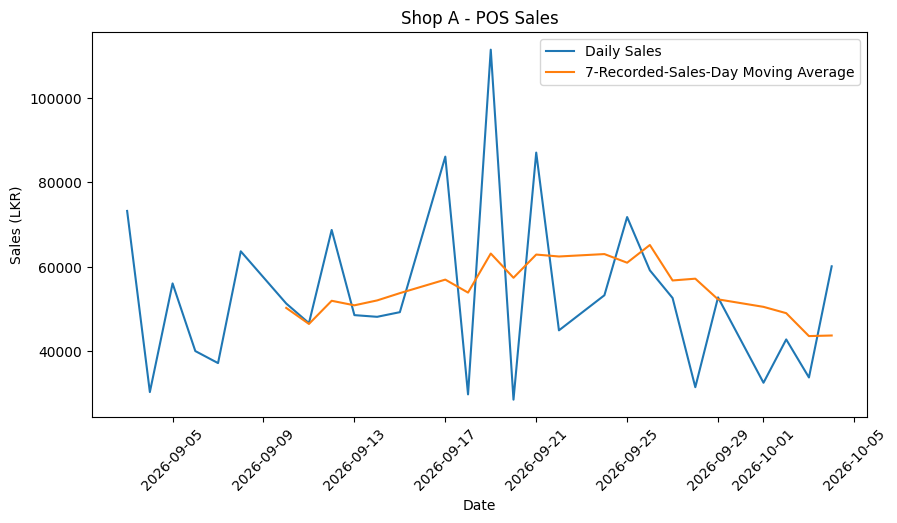

In [320]:
# Plot Shop A daily sales and moving average
plt.figure(figsize=(10, 5))

plt.plot(
    pos_daily_a["order_date"],
    pos_daily_a["total_sales"],
    label="Daily Sales"
)

plt.plot(
    pos_daily_a["order_date"],
    pos_daily_a["sales_ma_7"],
    label="7-Recorded-Sales-Day Moving Average"
)

plt.title("Shop A - POS Sales")
plt.xlabel("Date")
plt.ylabel("Sales (LKR)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

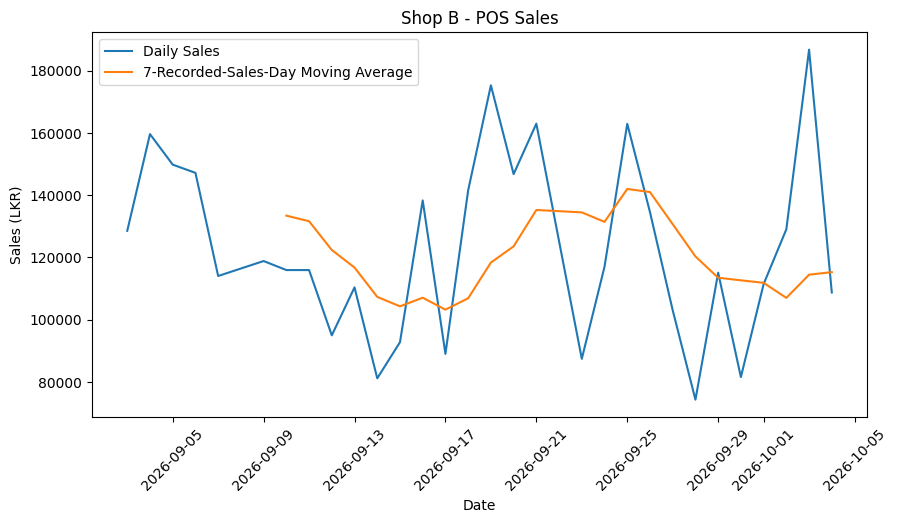

In [321]:
# Plot Shop B daily sales and moving average
plt.figure(figsize=(10, 5))

plt.plot(
    pos_daily_b["order_date"],
    pos_daily_b["total_sales"],
    label="Daily Sales"
)

plt.plot(
    pos_daily_b["order_date"],
    pos_daily_b["sales_ma_7"],
    label="7-Recorded-Sales-Day Moving Average"
)

plt.title("Shop B - POS Sales")
plt.xlabel("Date")
plt.ylabel("Sales (LKR)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

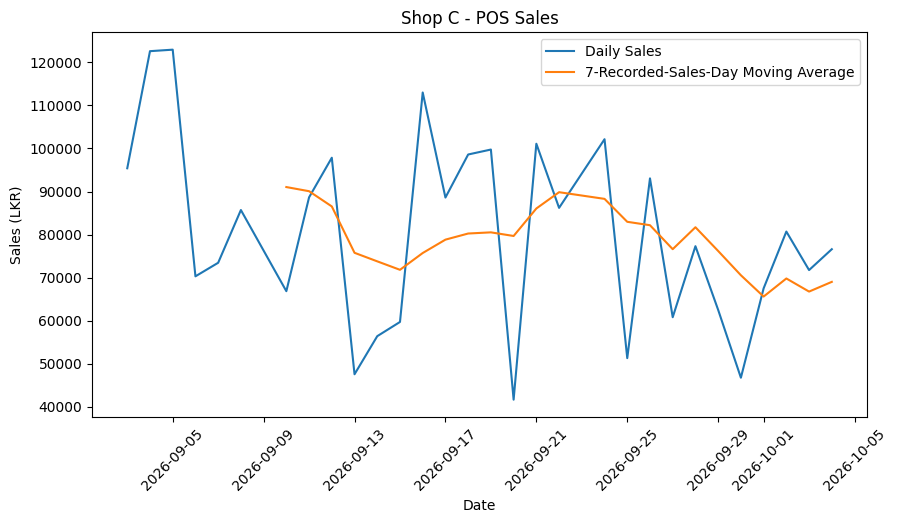

In [322]:
# Plot Shop C daily sales and moving average
plt.figure(figsize=(10, 5))

plt.plot(
    pos_daily_c["order_date"],
    pos_daily_c["total_sales"],
    label="Daily Sales"
)

plt.plot(
    pos_daily_c["order_date"],
    pos_daily_c["sales_ma_7"],
    label="7-Recorded-Sales-Day Moving Average"
)

plt.title("Shop C - POS Sales")
plt.xlabel("Date")
plt.ylabel("Sales (LKR)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## Comparison

In [323]:
# Manual vs POS comparison

comparison = pd.DataFrame({
    "Shop": ["A", "B", "C"],

    "Manual Avg Transactions/Day": [
        daily_a["transactions"].mean(),
        daily_b["transactions"].mean(),
        daily_c["transactions"].mean()
    ],

    "POS Avg Transactions/Day": [
        pos_daily_a["transactions"].mean(),
        pos_daily_b["transactions"].mean(),
        pos_daily_c["transactions"].mean()
    ],

    "Manual Avg Items/Day": [
        daily_a["total_items"].mean(),
        daily_b["total_items"].mean(),
        daily_c["total_items"].mean()
    ],

    "POS Avg Items/Day": [
        pos_daily_a["total_items"].mean(),
        pos_daily_b["total_items"].mean(),
        pos_daily_c["total_items"].mean()
    ],

    "Manual Avg Sales/Day": [
        daily_a["total_sales"].mean(),
        daily_b["total_sales"].mean(),
        daily_c["total_sales"].mean()
    ],

    "POS Avg Sales/Day": [
        pos_daily_a["total_sales"].mean(),
        pos_daily_b["total_sales"].mean(),
        pos_daily_c["total_sales"].mean()
    ],

    "Manual Avg Items/Transaction": [
        shop_a["total_items"].mean(),
        shop_b["total_items"].mean(),
        shop_c["total_items"].mean()
    ],

    "POS Avg Items/Transaction": [
        pos_a["total_items"].mean(),
        pos_b["total_items"].mean(),
        pos_c["total_items"].mean()
    ],

    "Manual Avg Transaction Value": [
        shop_a["order_total"].mean(),
        shop_b["order_total"].mean(),
        shop_c["order_total"].mean()
    ],

    "POS Avg Transaction Value": [
        pos_a["order_total"].mean(),
        pos_b["order_total"].mean(),
        pos_c["order_total"].mean()
    ]
})

comparison.round(2)

,Shop,Manual Avg Transactions/Day,POS Avg Transactions/Day,Manual Avg Items/Day,POS Avg Items/Day,Manual Avg Sales/Day,POS Avg Sales/Day,Manual Avg Items/Transaction,POS Avg Items/Transaction,Manual Avg Transaction Value,POS Avg Transaction Value
0,A,11.59,12.29,24.55,26.04,52756.03,53301.79,2.12,2.12,4553.35,4338.52
1,B,19.94,24.70,46.84,57.50,105661.29,123171.67,2.35,2.33,5300.16,4986.71
2,C,13.03,17.90,31.13,40.07,58493.33,80223.33,2.39,2.24,4487.98,4481.75


In [324]:
# Percentage change from manual to POS

comparison["Transactions Change %"] = (
    (comparison["POS Avg Transactions/Day"] - comparison["Manual Avg Transactions/Day"])
    / comparison["Manual Avg Transactions/Day"] * 100
)

comparison["Items Change %"] = (
    (comparison["POS Avg Items/Day"] - comparison["Manual Avg Items/Day"])
    / comparison["Manual Avg Items/Day"] * 100
)

comparison["Sales Change %"] = (
    (comparison["POS Avg Sales/Day"] - comparison["Manual Avg Sales/Day"])
    / comparison["Manual Avg Sales/Day"] * 100
)

comparison["Items/Transaction Change %"] = (
    (comparison["POS Avg Items/Transaction"] - comparison["Manual Avg Items/Transaction"])
    / comparison["Manual Avg Items/Transaction"] * 100
)

comparison["Transaction Value Change %"] = (
    (comparison["POS Avg Transaction Value"] - comparison["Manual Avg Transaction Value"])
    / comparison["Manual Avg Transaction Value"] * 100
)

comparison.round(2)

,Shop,Manual Avg Transactions/Day,POS Avg Transactions/Day,Manual Avg Items/Day,POS Avg Items/Day,Manual Avg Sales/Day,POS Avg Sales/Day,Manual Avg Items/Transaction,POS Avg Items/Transaction,Manual Avg Transaction Value,POS Avg Transaction Value,Transactions Change %,Items Change %,Sales Change %,Items/Transaction Change %,Transaction Value Change %
0,A,11.59,12.29,24.55,26.04,52756.03,53301.79,2.12,2.12,4553.35,4338.52,6.04,6.04,1.03,0.01,-4.72
1,B,19.94,24.70,46.84,57.50,105661.29,123171.67,2.35,2.33,5300.16,4986.71,23.90,22.76,16.57,-0.92,-5.91
2,C,13.03,17.90,31.13,40.07,58493.33,80223.33,2.39,2.24,4487.98,4481.75,37.34,28.69,37.15,-6.30,-0.14


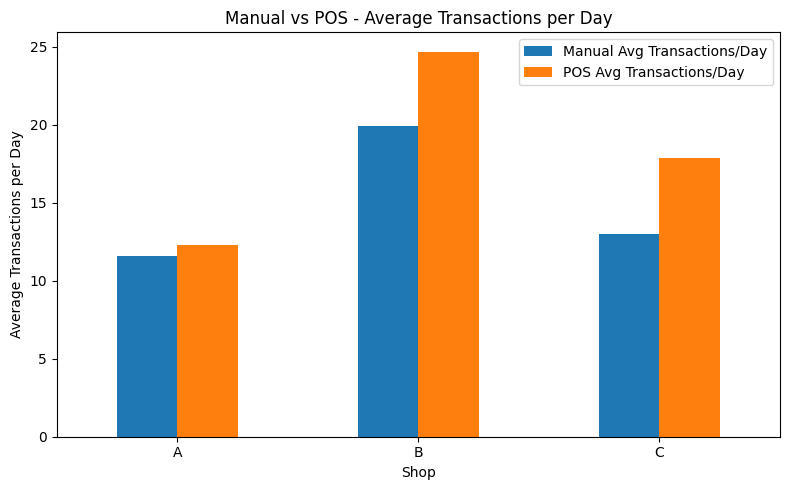

In [325]:
comparison.plot(
    x="Shop",
    y=["Manual Avg Transactions/Day", "POS Avg Transactions/Day"],
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Shop")
plt.ylabel("Average Transactions per Day")
plt.title("Manual vs POS - Average Transactions per Day")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

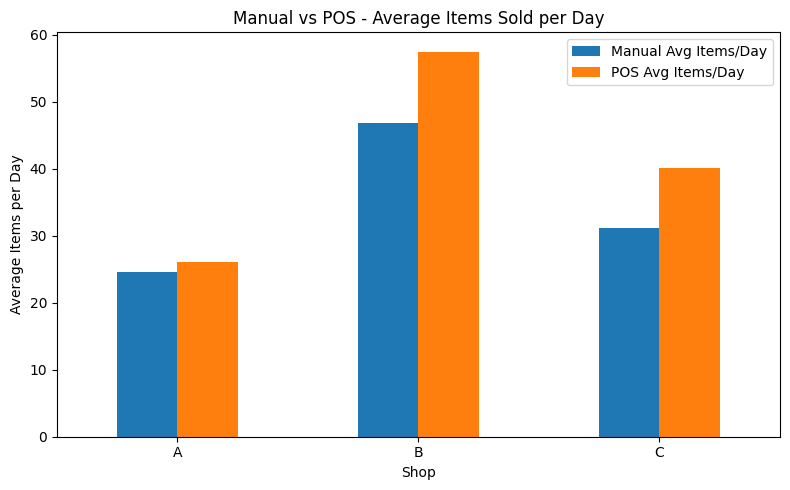

In [326]:
comparison.plot(
    x="Shop",
    y=["Manual Avg Items/Day", "POS Avg Items/Day"],
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Shop")
plt.ylabel("Average Items per Day")
plt.title("Manual vs POS - Average Items Sold per Day")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

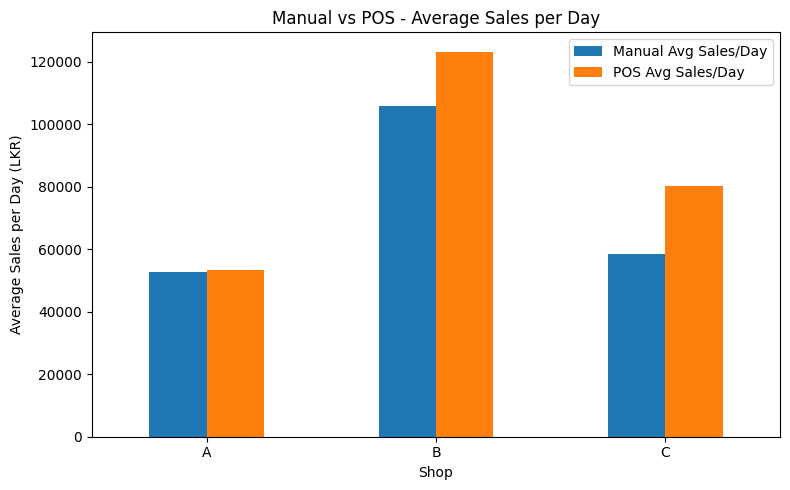

In [327]:
comparison.plot(
    x="Shop",
    y=["Manual Avg Sales/Day", "POS Avg Sales/Day"],
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Shop")
plt.ylabel("Average Sales per Day (LKR)")
plt.title("Manual vs POS - Average Sales per Day")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()